# Secondary RQ — Regular public transit & communication apprehension

**Sample:** Prolific File A + File B stacked ∩ Qualtrics File C, matched on `Q0` / `Participant id`, with complete PRCA group + interpersonal ground truth.

**Secondary research question:** Do individuals who take public transportation **regularly** have communication-apprehension (CA) scores that differ statistically from the larger matched cohort? If so, by how much — and what does the score distribution look like?

**Primary exposure (Q26):** public transportation days in the last 3 months.  
**Regular riders** = `4-8 days a month` **or** `8 or more days a month` (weekly-or-more).

This notebook:

1. Loads / cleans the matched analytic sample  
2. Labels regular vs non-regular riders  
3. Describes CA distributions  
4. Runs Welch *t*-tests + Mann–Whitney + bootstrap CIs + effect sizes  
5. Checks sensitivity across alternate Q26 cutoffs  
6. Writes distributable artifacts under `outputs/transit_ca/`


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ca_personas.load import load_full_cohort
from ca_personas.paths import sibling_data_available
from ca_personas.transit_ca import (
    PRIMARY_REGULAR_LABELS,
    run_transit_ca_analysis,
    save_transit_ca_artifacts,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

assert sibling_data_available(), (
    "Place File A/B/C under ../sibling_data/ before running this notebook."
)
print("Regular-rider labels:", sorted(PRIMARY_REGULAR_LABELS))


Regular-rider labels: ['4-8 days a month', '8 or more days a month']


## 1. Load matched analytic sample

Inner join of stacked Prolific waves with Qualtrics File C; keep respondents with complete PRCA items (`Q1–Q6`, `Q13–Q18`).


In [2]:
participants, cleaning_report = load_full_cohort(join_how="inner")
print(json.dumps(cleaning_report, indent=2))
print("Analytic N:", len(participants))
participants[["participant_id", "Q26", "gt_group_ca", "gt_interpersonal_ca"]].head()


{
  "n_prolific_raw": 262,
  "n_prolific_unique": 262,
  "n_qualtrics_raw": 273,
  "n_qualtrics_with_pid": 255,
  "n_qualtrics_complete_ca": 260,
  "n_joined": 252,
  "n_matched_both": 252,
  "n_analytic": 241,
  "n_dropped_missing_pid": 0,
  "n_dropped_incomplete_ca": 11,
  "n_dropped_unscorable_ca": 0,
  "n_dropped_unjoined": 31,
  "n_prolific_only": 10,
  "n_qualtrics_only": 21,
  "n_qualtrics_missing_pid": 18,
  "waves": {
    "B": 153,
    "A": 99
  },
  "notes": [
    "Normalized 19 DATA_EXPIRED Student status values to missing.",
    "Full Prolific waves (File A/B) omit Ethnicity / Nationality / Language; demos tier uses Age, Sex, Country of residence, and Student status.",
    "Analytic sample = Prolific\u2229Qualtrics with complete scorable PRCA group + interpersonal items.",
    "Merge coverage (pre-CA filter): 252 matched Prolific\u2229Qualtrics; 21 Qualtrics-only (incl. 18 blank Q0 test rows; disregard); 10 Prolific-only (disregard)."
  ]
}
Analytic N: 241


,participant_id,Q26,gt_group_ca,gt_interpersonal_ca
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,2-4 days a month,14,16
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,Never,17,17
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,Never,11,12
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,Never,10,6
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,Never,8,12


## 2. Run secondary-RQ analysis pipeline

Welch *t*-test (primary), Mann–Whitney (nonparametric sensitivity), Cohen's *d* / Hedges' *g*, and bootstrap 95% CIs for the mean difference (regular − not regular). Also reports regular mean vs overall cohort mean for the “how much vs the larger population” contrast.


In [3]:
analysis = run_transit_ca_analysis(participants, n_boot=5000, random_state=42)
summary = analysis["summary"]
print(json.dumps(summary, indent=2))


{
  "secondary_rq": "Do regular public-transit riders have CA scores that differ statistically from the larger matched cohort, and by how much?",
  "sample": {
    "n_analytic_input": 241,
    "n_with_q26": 241,
    "n_regular": 101,
    "n_not_regular": 140,
    "regular_definition": "Q26 in {4-8 days a month, 8 or more days a month} (weekly-or-more public transit)",
    "regular_labels": [
      "4-8 days a month",
      "8 or more days a month"
    ]
  },
  "primary_tests": [
    {
      "score": "gt_group_ca",
      "n_regular": 101,
      "n_not_regular": 140,
      "n_overall": 241,
      "mean_regular": 13.03960396039604,
      "mean_not_regular": 15.764285714285714,
      "mean_overall": 14.622406639004149,
      "diff_regular_minus_not_regular": -2.7246817538896746,
      "diff_regular_minus_overall": -1.5828026786081093,
      "pct_diff_vs_overall": -10.824501859947627,
      "welch_t": -3.676531638712411,
      "welch_df": 236.9131613823941,
      "welch_p": 0.00029250822800

## 3. Exposure frequencies (Q26)


In [4]:
labeled = analysis["labeled"]
exposure = labeled.dropna(subset=["regular_transit"])
print(exposure["Q26"].value_counts(dropna=False))
print()
print(exposure["transit_group"].value_counts())
print(
    f"Regular share: {(exposure['regular_transit'] == True).mean():.1%} "
    f"({int((exposure['regular_transit'] == True).sum())}/{len(exposure)})"
)


Q26
8 or more days a month    55
2-4 days a month          53
Never                     50
4-8 days a month          46
0-1 days a month          37
Name: count, dtype: int64

transit_group
not_regular    140
regular        101
Name: count, dtype: int64
Regular share: 41.9% (101/241)


## 4. Descriptive CA by transit group


In [5]:
analysis["descriptives"]


,score,group,n,mean,std,median,min,max,q25,q75
0,gt_group_ca,overall,241,14.6224,6.0328,13.0000,6.0000,30.0000,10.0000,18.0000
1,gt_group_ca,regular,101,13.0396,5.0772,12.0000,6.0000,27.0000,10.0000,16.0000
2,gt_group_ca,not_regular,140,15.7643,6.4156,14.0000,6.0000,30.0000,11.0000,20.2500
3,gt_interpersonal_ca,overall,241,14.3112,5.8180,13.0000,6.0000,30.0000,10.0000,18.0000
4,gt_interpersonal_ca,regular,101,13.3069,5.3661,13.0000,6.0000,30.0000,10.0000,16.0000
5,gt_interpersonal_ca,not_regular,140,15.0357,6.0387,14.0000,6.0000,30.0000,11.0000,18.2500


In [6]:
analysis["by_q26"]


,Q26,n,mean_group_ca,std_group_ca,mean_interpersonal_ca,std_interpersonal_ca,median_group_ca,median_interpersonal_ca
0,Never,50,17.3800,6.8836,16.3400,6.9388,16.0000,16.0000
1,0-1 days a month,37,15.3784,5.8279,15.1622,5.2362,14.0000,14.0000
2,2-4 days a month,53,14.5094,6.1351,13.7170,5.4504,13.0000,12.0000
3,4-8 days a month,46,13.2826,4.8884,13.4783,5.1585,12.0000,13.0000
4,8 or more days a month,55,12.8364,5.2661,13.1636,5.5769,12.0000,12.0000


## 5. Inferential tests — regular vs not-regular (and vs overall mean)


In [7]:
comps = analysis["comparisons"].copy()
show_cols = [
    "score", "n_regular", "n_not_regular",
    "mean_regular", "mean_not_regular", "mean_overall",
    "diff_regular_minus_not_regular", "diff_regular_minus_overall",
    "pct_diff_vs_overall",
    "welch_t", "welch_p", "mannwhitney_p",
    "cohens_d", "hedges_g",
    "boot_ci_low", "boot_ci_high", "significant_at_05",
]
comps[show_cols]


,score,n_regular,n_not_regular,mean_regular,mean_not_regular,mean_overall,diff_regular_minus_not_regular,diff_regular_minus_overall,pct_diff_vs_overall,welch_t,welch_p,mannwhitney_p,cohens_d,hedges_g,boot_ci_low,boot_ci_high,significant_at_05
0,gt_group_ca,101,140,13.0396,15.7643,14.6224,-2.7247,-1.5828,-10.8245,-3.6765,0.0003,0.0015,-0.4624,-0.4609,-4.1454,-1.2844,True
1,gt_interpersonal_ca,101,140,13.3069,15.0357,14.3112,-1.7288,-1.0043,-7.0174,-2.3405,0.0201,0.0249,-0.2998,-0.2988,-3.1221,-0.2536,True


In [8]:
# Plain-language results card
for row in summary["primary_tests"]:
    score = "Group CA" if row["score"] == "gt_group_ca" else "Interpersonal CA"
    direction = "lower" if row["diff_regular_minus_overall"] < 0 else "higher"
    sig = "YES" if row["significant_at_05"] else "no"
    print(
        f"{score}: regular M={row['mean_regular']:.2f} vs overall M={row['mean_overall']:.2f} "
        f"(Δ={row['diff_regular_minus_overall']:+.2f} pts, {row['pct_diff_vs_overall']:+.1f}%); "
        f"vs non-regular Δ={row['diff_regular_minus_not_regular']:+.2f} "
        f"[95% boot CI {row['boot_ci_low']:+.2f}, {row['boot_ci_high']:+.2f}]; "
        f"Welch p={row['welch_p']:.4f}; Cohen d={row['cohens_d']:.3f}; significant@0.05={sig}"
    )
print()
print("Verdict:", summary["verdict"]["interpretation"])


Group CA: regular M=13.04 vs overall M=14.62 (Δ=-1.58 pts, -10.8%); vs non-regular Δ=-2.72 [95% boot CI -4.15, -1.28]; Welch p=0.0003; Cohen d=-0.462; significant@0.05=YES
Interpersonal CA: regular M=13.31 vs overall M=14.31 (Δ=-1.00 pts, -7.0%); vs non-regular Δ=-1.73 [95% boot CI -3.12, -0.25]; Welch p=0.0201; Cohen d=-0.300; significant@0.05=YES

Verdict: At least one PRCA subscale differs significantly (Welch t, α=.05) between regular and non-regular riders.


## 6. Distributions for reporting


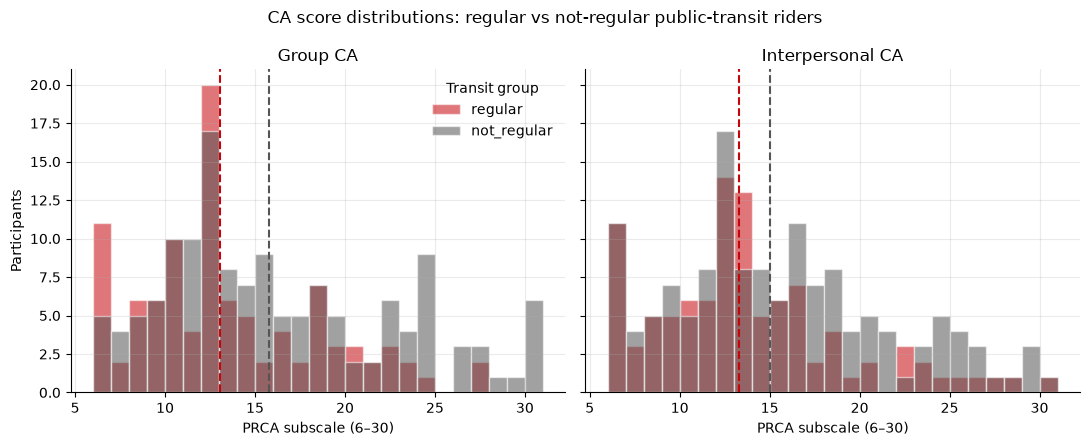

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
colors = {"regular": "#C5050C", "not_regular": "#555555"}
for ax, score, title in zip(
    axes,
    ["gt_group_ca", "gt_interpersonal_ca"],
    ["Group CA", "Interpersonal CA"],
):
    for group, color in colors.items():
        vals = labeled.loc[labeled["transit_group"] == group, score].dropna()
        ax.hist(vals, bins=range(6, 32), alpha=0.55, label=group, color=color, edgecolor="white")
        ax.axvline(vals.mean(), color=color, linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("PRCA subscale (6–30)")
axes[0].set_ylabel("Participants")
axes[0].legend(frameon=False, title="Transit group")
fig.suptitle("CA score distributions: regular vs not-regular public-transit riders")
fig.tight_layout()
OUT = ROOT / "outputs" / "transit_ca"
OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / "fig_ca_distributions_by_transit.png", dpi=150)
plt.show()


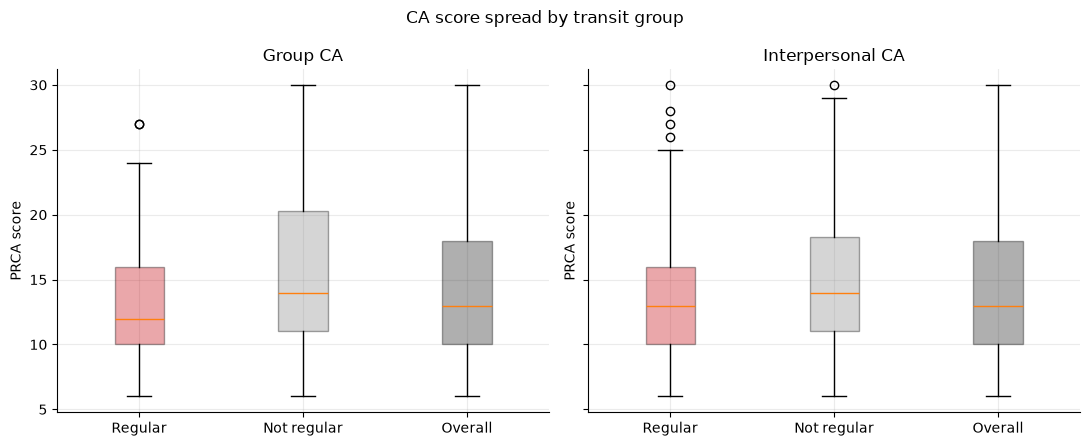

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, score, title in zip(
    axes,
    ["gt_group_ca", "gt_interpersonal_ca"],
    ["Group CA", "Interpersonal CA"],
):
    data = [
        labeled.loc[labeled["transit_group"] == "regular", score].dropna(),
        labeled.loc[labeled["transit_group"] == "not_regular", score].dropna(),
        labeled[score].dropna(),
    ]
    bp = ax.boxplot(data, tick_labels=["Regular", "Not regular", "Overall"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#C5050C", "#888888", "#1a1a1a"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.set_title(title)
    ax.set_ylabel("PRCA score")
fig.suptitle("CA score spread by transit group")
fig.tight_layout()
fig.savefig(OUT / "fig_ca_boxplots_by_transit.png", dpi=150)
plt.show()


## 7. Band prevalence (low / moderate / high)


In [11]:
analysis["bands"]


,band_col,group,n,low_n,low_pct,moderate_n,moderate_pct,high_n,high_pct
0,gt_group_band,overall,241,130,0.5394,61,0.2531,50,0.2075
1,gt_group_band,regular,101,65,0.6436,23,0.2277,13,0.1287
2,gt_group_band,not_regular,140,65,0.4643,38,0.2714,37,0.2643
3,gt_interpersonal_band,overall,241,128,0.5311,69,0.2863,44,0.1826
4,gt_interpersonal_band,regular,101,63,0.6238,25,0.2475,13,0.1287
5,gt_interpersonal_band,not_regular,140,65,0.4643,44,0.3143,31,0.2214


## 8. Sensitivity — alternate definitions of “regular”


In [12]:
sens = analysis["sensitivity"]
sens[[
    "cutoff", "score", "n_regular", "n_not_regular",
    "mean_regular", "mean_not_regular", "mean_overall",
    "diff_regular_minus_not_regular", "diff_regular_minus_overall",
    "welch_p", "cohens_d", "significant_at_05", "regular_labels",
]]


,cutoff,score,n_regular,n_not_regular,mean_regular,mean_not_regular,mean_overall,diff_regular_minus_not_regular,diff_regular_minus_overall,welch_p,cohens_d,significant_at_05,regular_labels
0,weekly_plus,gt_group_ca,101,140,13.0396,15.7643,14.6224,-2.7247,-1.5828,0.0003,-0.4624,True,4-8 days a month; 8 or more days a month
1,weekly_plus,gt_interpersonal_ca,101,140,13.3069,15.0357,14.3112,-1.7288,-1.0043,0.0201,-0.2998,True,4-8 days a month; 8 or more days a month
2,twice_monthly_plus,gt_group_ca,154,87,13.5455,16.5287,14.6224,-2.9833,-1.0770,0.0004,-0.5081,True,2-4 days a month; 4-8 days a month; 8 or more ...
3,twice_monthly_plus,gt_interpersonal_ca,154,87,13.4481,15.8391,14.3112,-2.3910,-0.8632,0.0032,-0.4184,True,2-4 days a month; 4-8 days a month; 8 or more ...
4,any_use,gt_group_ca,191,50,13.9005,17.3800,14.6224,-3.4795,-0.7219,0.0015,-0.5920,True,0-1 days a month; 2-4 days a month; 4-8 days a...
5,any_use,gt_interpersonal_ca,191,50,13.7801,16.3400,14.3112,-2.5599,-0.5311,0.0181,-0.4463,True,0-1 days a month; 2-4 days a month; 4-8 days a...
6,heavy_only,gt_group_ca,55,186,12.8364,15.1505,14.6224,-2.3142,-1.7860,0.0070,-0.3879,True,8 or more days a month
7,heavy_only,gt_interpersonal_ca,55,186,13.1636,14.6505,14.3112,-1.4869,-1.1476,0.0894,-0.2565,False,8 or more days a month


## 9. Write distributable artifacts

Tables + JSON results card land in `outputs/transit_ca/` (gitignored). Use these for the manuscript / slides.


In [13]:
paths = save_transit_ca_artifacts(analysis, OUT)
# Also persist the cleaned analytic sample used here.
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
participants.to_csv(processed / "participants_scored.csv", index=False)
(processed / "cleaning_report.json").write_text(json.dumps(cleaning_report, indent=2))
{k: str(v) for k, v in paths.items()}


{'descriptives': '/workspace/outputs/transit_ca/transit_ca_descriptives.csv',
 'comparisons': '/workspace/outputs/transit_ca/transit_ca_comparisons.csv',
 'bands': '/workspace/outputs/transit_ca/transit_ca_band_prevalence.csv',
 'by_q26': '/workspace/outputs/transit_ca/transit_ca_by_q26.csv',
 'sensitivity': '/workspace/outputs/transit_ca/transit_ca_sensitivity.csv',
 'distribution': '/workspace/outputs/transit_ca/transit_ca_score_distribution.csv',
 'labeled': '/workspace/outputs/transit_ca/transit_ca_labeled_sample.csv',
 'summary': '/workspace/outputs/transit_ca/transit_ca_summary.json',
 'results_card': '/workspace/outputs/transit_ca/transit_ca_results_card.json'}

## 10. Takeaway (auto-filled from results card)

The cell below prints the takeaway from `summary` / `transit_ca_summary.json` so this section never carries blank placeholders.


In [14]:
def _cohen_size(d: float) -> str:
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    if ad < 0.5:
        return "small"
    if ad < 0.8:
        return "medium"
    return "large"

sample = summary["sample"]
print("Regular definition:", sample["regular_definition"])
print(f"N regular / N comparison: {sample['n_regular']} / {sample['n_not_regular']}")
for row in summary["primary_tests"]:
    label = "Group CA" if row["score"] == "gt_group_ca" else "Interpersonal CA"
    print(
        f"{label}: mean difference vs overall = {row['diff_regular_minus_overall']:+.2f} pts; "
        f"Welch p = {row['welch_p']:.4g}; d = {row['cohens_d']:.3f} "
        f"({_cohen_size(row['cohens_d'])})."
    )
any_sig = summary["verdict"]["any_subscale_significant_at_05"]
ds = [abs(r["cohens_d"]) for r in summary["primary_tests"]]
mag = _cohen_size(max(ds)) if ds else "unknown"
print(
    "Conclusion: regular riders "
    + ("DO" if any_sig else "do NOT")
    + " differ significantly from the larger cohort under α = .05; "
    f"largest |d| magnitude is {mag}."
)
print("Interpretation:", summary["verdict"]["interpretation"])


Regular definition: Q26 in {4-8 days a month, 8 or more days a month} (weekly-or-more public transit)
N regular / N comparison: 101 / 140
Group CA: mean difference vs overall = -1.58 pts; Welch p = 0.0002925; d = -0.462 (small).
Interpersonal CA: mean difference vs overall = -1.00 pts; Welch p = 0.02012; d = -0.300 (small).
Conclusion: regular riders DO differ significantly from the larger cohort under α = .05; largest |d| magnitude is small.
Interpretation: At least one PRCA subscale differs significantly (Welch t, α=.05) between regular and non-regular riders.
